In [3]:
import os
import cv2
import  numpy as np
import random
import glob as glob
from ultralytics import YOLO
from pexelsapi.pexels import Pexels
import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:

koala_video_path = "videos/koala_video1.mp4"
colibri_video_path = "videos/colibri_video1.mp4"
PEXELS_KEY = "fdmnaf3q0usOwaMzOIU0FWjE6CEgMvRYSfEEjywCn32H0c4cZSLN2PrI"
api = Pexels(PEXELS_KEY)

#search_results = api.search_photos(query="lion", orientation="landscape", size="large")
#search_results

NameError: name 'search_results' is not defined

In [ ]:
import requests

def search_low_quality(search_results):
    low_res_video = None
    minWidth = 4000
    for video_file in search_results["videos"][0]["video_files"]:
        if video_file["width"] < minWidth:
            minWidth = video_file["width"]
            low_res_video = video_file["link"]

    return low_res_video


video_link = search_low_quality(search_results)
print(video_link)

In [ ]:
import requests

def download_video(url, save_path):
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        with open(save_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
        print(f"Video downloaded successfully to {save_path}")

    except Exception as e:
        print(f"Video could not be loaded: {e}")

# Use it like this:
download_video(video_link, "./content/videos/lion_video1.mp4")

## Dataset creation

In [ ]:
img_tags = ["wildlife", "nature", "forest animals", "safari", "wilderness", "national park"]
species_tags = ["pigeon", "fox", "wolf", "bear", "frog" "roe deer", "wild boar", "red squirrel", "common buzzard"]

all_tags = img_tags + species_tags
all_tags

In [ ]:
all_tags2 = ["elephant", "polar bear", "lion", "gorilla", "waterfowl",
             "butterfly", "zebra", "turtle", "bald eagle"]

In [ ]:
import requests
import os

def download_photo(url, idx):
    folder = "content/images"
    os.makedirs(folder, exist_ok=True)
    file_path = os.path.join(folder, f"image_{idx}.jpg")

    try:
        response = requests.get(url, timeout=10)
        # Only save if the request was successful (Status 200)
        if response.status_code == 200:
            with open(file_path, "wb") as f:
                f.write(response.content)
        else:
            print(f"Failed to download image {idx}. Status: {response.status_code}")
    except Exception as e:
        print(f"Error downloading image {idx}: {e}")

# --- Main Loop ---
photos_count = 0
for tag in all_tags2:
    # Use the pexels_api library search
    results = api.search_photos(query=tag, orientation="landscape", per_page=5)

    # The 'results' object is a dictionary, not a direct iterable of photos.
    # We need to access the 'photos' key, which contains a list of photo dictionaries.
    for photo_dict in results["photos"]:
        # Each 'photo_dict' is a dictionary, so access its keys
        url = photo_dict["src"]["original"]
        download_photo(url, photos_count)
        photos_count += 1 

print(f"✅ {photos_count} photos saved successfully in 'content/images/'")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
all_tags = all_tags + all_tags2
all_tags

## Label Images using Autodistill autolabeling


In [ ]:
from autodistill_grounding_dino import GroundingDINO
from autodistill.detection import CaptionOntology

ontology_dict = {
    f"Phot of a {tag}": tag for tag in all_tags
}
ontology = CaptionOntology(ontology_dict)

base_model = GroundingDINO(ontology=ontology)
dataset = base_model.label(
    input_folder="content/images",
    extension=".jpg",
    output_folder="content/dataset"
)

In [ ]:
%pip install roboflow

## YOLO Model training

In [ ]:
import os
# This MUST be set before importing YOLO
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

# 1. Update Ultralytics to the latest version
!pip install -U ultralytics --quiet

from ultralytics import YOLO

# 2. Re-download a clean model file to fix potential corruption
if os.path.exists("yolov8n.pt"):
    !rm yolov8n.pt

# 3. Load and train
model = YOLO("yolov8n.pt")
model.train(data="/content/dataset/data.yaml", epochs=50, imgsz=640)

## Test Animal detection using pretrained YOLO

In [4]:
model = YOLO("yolov8s.pt")

In [15]:
results = model.predict("../image.png")


image 1/1 c:\Users\aliap\OneDrive\ \WildFrame\WildlifeDetector\..\image.png: 448x640 1 cat, 586.2ms
Speed: 83.5ms preprocess, 586.2ms inference, 33.3ms postprocess per image at shape (1, 3, 448, 640)



image 1/1 c:\Users\aliap\OneDrive\ \WildFrame\WildlifeDetector\..\image.png: 448x640 1 cat, 277.6ms
Speed: 8.5ms preprocess, 277.6ms inference, 5.9ms postprocess per image at shape (1, 3, 448, 640)
Detected: cat (confidence: 92.19%)
- cat: 92.19%


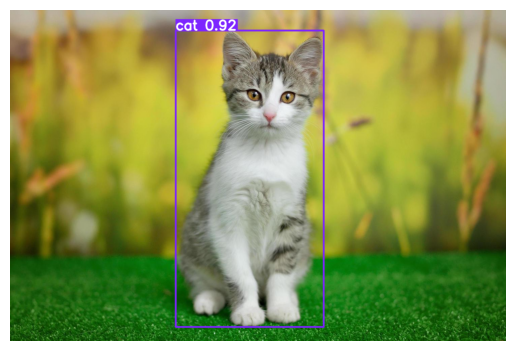

In [18]:
# Run prediction
results = model.predict("../image.png")

# Get the first result (if multiple images, iterate through results)
result = results[0]

# Check if any objects were detected
if len(result.boxes) > 0:
    # Get the first detected object
    box = result.boxes[0]
    
    # Get class ID and name
    class_id = int(box.cls[0])
    class_name = result.names[class_id]  # Animal name
    
    # Get confidence score
    confidence = float(box.conf[0])
    
    print(f"Detected: {class_name} (confidence: {confidence:.2%})")
    
    # Get all detections
    for box in result.boxes:
        class_id = int(box.cls[0])
        animal = result.names[class_id]
        conf = float(box.conf[0])
        print(f"- {animal}: {conf:.2%}")
else:
    print("No animals detected")

# Visualize with bounding boxes
annotated_image = result.plot()  # Returns image with boxes drawn
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [ ]:
def classify_animal(image_path):
    name = None
    results = model.predict(image_path)
    result = results[0]

    if len(result.boxes) > 0:
        box = result.boxes[0]
        class_id = int(box.cls[0])
        name = result.names[class_id]
    
    return name

